# ResNet18 — LoRA
Replace conv layers with LoRA-wrapped equivalents; train only LoRA weights + head.

In [1]:
import os

os.chdir("..")  
print(os.getcwd())

/Users/peter/Documents/MDS_UBC/DATA_586/food_classification


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import loralib as lora
from torchvision.models import ResNet18_Weights

from helpers import (
    get_device, get_food101_loaders, replace_module_by_name, to_int,
    run_training, plot_results, count_trainable_params
)

In [3]:
def build_resnet18_lora(num_classes: int = 101, r: int = 8, alpha: int = 16):
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    target_layers = [
        "layer1.0.conv1", "layer1.0.conv2", "layer1.1.conv1", "layer1.1.conv2",
        "layer2.0.conv1", "layer2.0.conv2", "layer2.1.conv1", "layer2.1.conv2",
        "layer3.0.conv1", "layer3.0.conv2", "layer3.1.conv1", "layer3.1.conv2",
        "layer4.0.conv1", "layer4.0.conv2", "layer4.1.conv1", "layer4.1.conv2",
    ]

    for name, module in list(model.named_modules()):
        if name in target_layers and isinstance(module, nn.Conv2d):
            new_layer = lora.Conv2d(
                in_channels=module.in_channels,
                out_channels=module.out_channels,
                kernel_size=to_int(module.kernel_size),
                stride=to_int(module.stride),
                padding=to_int(module.padding),
                dilation=to_int(module.dilation),
                groups=module.groups,
                bias=(module.bias is not None),
                r=r, lora_alpha=alpha,
            )
            new_layer.conv.weight.data.copy_(module.weight.data)
            if module.bias is not None:
                new_layer.conv.bias.data.copy_(module.bias.data)
            replace_module_by_name(model, name, new_layer)

    lora.mark_only_lora_as_trainable(model)
    for p in model.fc.parameters():
        p.requires_grad = True

    return model

In [4]:
weights   = ResNet18_Weights.DEFAULT
transform = weights.transforms()

train_loader, val_loader = get_food101_loaders(transform, batch_size=128, num_workers=4)

model = build_resnet18_lora(num_classes=101, r=8, alpha=16)
print(f"Trainable params: {count_trainable_params(model):,}")

Trainable params: 572,517


In [5]:
model, train_losses, val_losses, train_accs, val_accs = run_training(
    model=model,
    model_name="resnet18_lora",
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=8,
    lr=1e-3,
)

[resnet18_lora] Final checkpoint found — loading metrics for plotting.


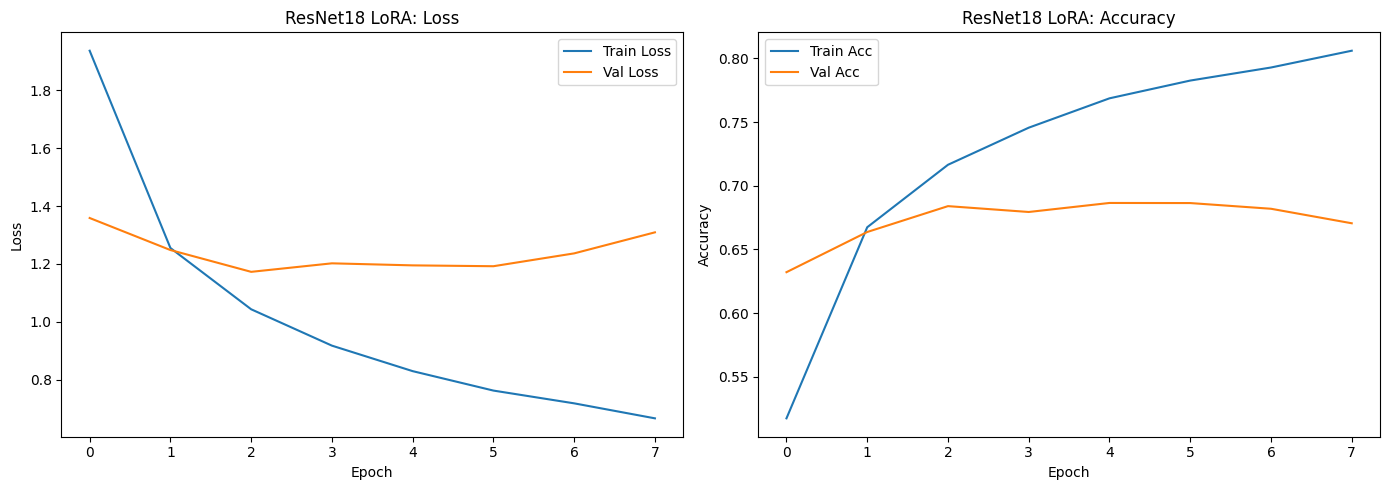

In [6]:
plot_results(train_losses, val_losses, train_accs, val_accs, "ResNet18 LoRA")